# 03 - Bloom Filters

Here is a task that looks impossible.

A stream delivers a billion events. For each one you must answer: *have I processed this before?*
If you keep every event id in a `set`, you need something like 160 GB, so the honest answer on one
machine is "I cannot". The usual escape routes are to downsample, to spin up a cluster, or to give
up on exactness quietly and hope.

There is another option, and it is the reason this project exists. A **Bloom filter** answers the
question in about 9.6 bits per item - 1.2 GB for that billion, and 1.2 MB for a million - and it
does so with an error that is *one-sided*:

> It will sometimes claim it has seen an event it has not. It will **never** claim it has not seen
> an event it has.

That asymmetry is not a technicality; it is the entire product. A deduplication filter that says
"new" when the item is old would corrupt your data. One that occasionally says "seen" about a
genuinely new item just skips a record - a cost you can dial down to whatever rate you can afford,
using a formula, before you write a line of code.

In [1]:
%matplotlib inline

import pandas as pd

from src.config import get_settings
from src.data import generate_unique_items
from src.evaluation.comparison import compare_membership, deep_sizeof
from src.evaluation.error_analysis import bloom_error_curve, bloom_memory_projection
from src.probabilistic.bloom import BloomFilter, measure_false_positive_rate, sizing
from src.probabilistic.counting_bloom import CountingBloomFilter
from src.results import results_dir, save_results
from src.visualisation import plot_bloom_error_curve, plot_memory_projection, save_figure

SETTINGS = get_settings()
SEED = SETTINGS.seed
N_ITEMS = SETTINGS.bloom.expected_items
TARGET = SETTINGS.bloom.target_fp_rate

print(f"seed = {SEED}, sizing for {N_ITEMS:,} items at a {TARGET:.1%} false-positive rate")

seed = 20260903, sizing for 100,000 items at a 1.0% false-positive rate


## The structure is a bit array and k hashes

To **add** an item: hash it k ways, set those k bits. To **test** it: hash it k ways, check whether
all k bits are set. There is nothing else. No keys are stored, which is exactly why it is small -
and exactly why it can never tell you *what* it has seen, only whether it might have.

The one-sided error falls straight out of that. A bit is only ever set by an item that was added,
so if any of an item's k bits is clear, that item was definitely never added. `False` is always the
truth. `True` means "all k bits happen to be set", which is true for every added item and, by bad
luck, for some others.

In [2]:
demo = BloomFilter(expected_items=1_000, target_fp_rate=0.01, seed=SEED)
demo.add("event-000001")

print(demo)
print()
print(f"'event-000001' in filter : {'event-000001' in demo}   <- added, always True")
print(f"'event-000002' in filter : {'event-000002' in demo}   <- not added, almost always False")
print()
print(f"bits set after one item  : {demo.bits_set} (k = {demo.n_hashes} hashes)")
print(f"whole filter is          : {demo.memory_bytes():,} bytes for 1,000 items")

BloomFilter(expected_items=1000, target_fp_rate=0.01, n_bits=9586, n_hashes=7)

'event-000001' in filter : True   <- added, always True
'event-000002' in filter : False   <- not added, almost always False

bits set after one item  : 7 (k = 7 hashes)
whole filter is          : 1,199 bytes for 1,000 items


## Sizing it, before allocating anything

Two numbers you know - how many items `n`, and what error rate `p` you can live with - determine
the geometry (Bloom, 1970):

```
m = -n ln(p) / (ln 2)^2      bits
k = (m / n) ln 2             hash functions
```

The striking part is the third column below: **bits per item does not depend on `n` at all**. One
percent costs 9.6 bits per item whether you are tracking a thousand items or a billion. Halving the
error rate costs about 1.44 more bits each - error falls exponentially in memory, which is why the
curve later in this notebook is so steep.

In [3]:
geometries = pd.DataFrame(
    [
        {
            "target_fp_rate": target,
            "bits_per_item": sizing(N_ITEMS, target).bits_per_item,
            "n_hashes": sizing(N_ITEMS, target).n_hashes,
            f"bytes_for_{N_ITEMS//1000}k_items": sizing(N_ITEMS, target).memory_bytes,
            "bytes_for_1bn_items": sizing(1_000_000_000, target).memory_bytes,
        }
        for target in SETTINGS.bloom.fp_targets
    ]
)
geometries

,target_fp_rate,bits_per_item,n_hashes,bytes_for_100k_items,bytes_for_1bn_items
0,0.1000,4.79253,3,59907,599066149
1,0.0500,6.23523,4,77941,779403029
2,0.0100,9.58506,7,119814,1198132298
3,0.0010,14.37759,10,179720,1797198446
4,0.0001,19.17012,13,239627,2396264595


## The guarantee, measured

Fill a filter to its design capacity, then ask it about every item it holds (there must be no
misses) and about a hundred thousand items it has never seen (there will be some hits, at the rate
we asked for).

In [4]:
items = generate_unique_items(N_ITEMS, seed=SEED, prefix="event-")
absent = [f"never-seen-{i:09d}" for i in range(100_000)]

bloom = BloomFilter(expected_items=N_ITEMS, target_fp_rate=TARGET, seed=SEED)
bloom.add_many(items)

false_negatives = int((~bloom.contains_many(items)).sum())
measured_fp, n_queries = measure_false_positive_rate(bloom, absent)

print(f"items added            : {len(bloom):,}")
print(f"memory                 : {bloom.memory_bytes():,} bytes "
      f"({bloom.n_bits / N_ITEMS:.2f} bits per item)")
print(f"bits set               : {bloom.fill_ratio:.1%} of the array")
print()
print(f"FALSE NEGATIVES        : {false_negatives}  <- zero, always, by construction")
print(f"false positives        : {measured_fp:.4%} over {n_queries:,} unseen items")
print(f"theory said            : {bloom.theoretical_fp_rate():.4%}")

items added            : 100,000
memory                 : 119,814 bytes (9.59 bits per item)
bits set               : 51.8% of the array

FALSE NEGATIVES        : 0  <- zero, always, by construction
false positives        : 0.9880% over 100,000 unseen items
theory said            : 1.0039%


In [5]:
saved = save_results(
    {
        "n_items": N_ITEMS,
        "target_fp_rate": TARGET,
        "n_bits": bloom.n_bits,
        "n_hashes": bloom.n_hashes,
        "bits_per_item": bloom.n_bits / N_ITEMS,
        "memory_bytes": bloom.memory_bytes(),
        "fill_ratio": bloom.fill_ratio,
        "false_negatives": false_negatives,
        "measured_fp_rate": measured_fp,
        "theoretical_fp_rate": bloom.theoretical_fp_rate(),
        "n_absent_queries": n_queries,
        "geometries": geometries,
    },
    "03_bloom_guarantee",
)
print("saved ->", saved.name)

saved -> 03_bloom_guarantee.json


## Memory buys accuracy - the figure that sells the idea

Every point is a real filter, filled to capacity, measured against 100,000 unseen items. The dashed
line is the formula. They sit on top of each other, which is the useful part: you can *choose* your
error rate in advance and get it.

Read the axes as a price list. Going from a 10% error to a 0.01% error - a thousandfold
improvement - costs four times the memory. That is the trade this whole project is about.

In [6]:
curve = bloom_error_curve(
    expected_items=N_ITEMS,
    fp_targets=SETTINGS.bloom.fp_targets,
    n_queries=100_000,
    seed=SEED,
)
curve.round(6)

,target_fp_rate,n_bits,n_hashes,bits_per_item,memory_bytes,fill_ratio,theoretical_fp_rate,measured_fp_rate,false_negatives
0,0.1000,479253,3,4.79253,59907,0.464615,0.100713,0.10046,0
1,0.0500,623523,4,6.23523,77941,0.473994,0.050269,0.05073,0
2,0.0100,958506,7,9.58506,119814,0.517995,0.010039,0.01011,0
3,0.0010,1437759,10,14.37759,179720,0.500734,0.001000,0.00097,0
4,0.0001,1917012,13,19.17012,239627,0.492772,0.000100,0.00013,0


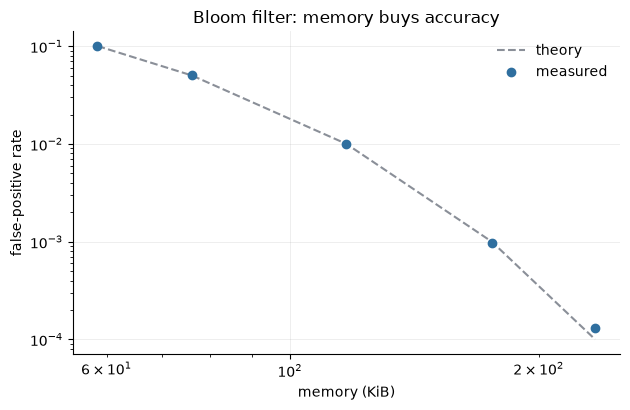

In [7]:
figure = plot_bloom_error_curve(curve)
save_figure(figure, "03_memory_vs_error")
figure

In [8]:
saved = save_results(
    {
        "curve": curve,
        "n_queries": 100_000,
        "false_negatives_total": int(curve["false_negatives"].sum()),
        "note": (
            "Measured false-positive rates sit on the theoretical curve, and the false-negative "
            "column is zero in every row - the guarantee, not an average."
        ),
    },
    "03_memory_vs_error",
)
print("saved ->", saved.name)

saved -> 03_memory_vs_error.json


## What happens if you get `n` wrong

Size a filter for a million items and push five million through it. The bit array saturates, more
unseen items find all their bits set, and the false-positive rate climbs - eventually to 1, where
the filter says "seen" about everything and is useless.

Note what does *not* happen. Even at three times its design capacity, the false-negative count is
still zero. Overfilling makes a Bloom filter **wrong more often, never wrong in a new way** - the
failure is gradual and one-sided, which is a rare and comfortable property in an engineering
component.

In [9]:
overfill_rows = []
capacity = 20_000
absent_sample = absent[:50_000]

for multiple in (0.5, 1.0, 2.0, 3.0, 5.0):
    n_added = int(capacity * multiple)
    stressed = BloomFilter(expected_items=capacity, target_fp_rate=0.01, seed=SEED)
    added = items[:n_added]
    stressed.add_many(added)
    overfill_rows.append(
        {
            "times_design_capacity": multiple,
            "items_added": n_added,
            "fill_ratio": stressed.fill_ratio,
            "measured_fp_rate": float(stressed.contains_many(absent_sample).mean()),
            "theoretical_fp_rate": stressed.theoretical_fp_rate(),
            "false_negatives": int((~stressed.contains_many(added)).sum()),
        }
    )

overfill = pd.DataFrame(overfill_rows)
saved = save_results({"overfill": overfill, "design_capacity": capacity}, "03_overfill")
print("saved ->", saved.name)
overfill.round(4)

saved -> 03_overfill.json


,times_design_capacity,items_added,fill_ratio,measured_fp_rate,theoretical_fp_rate,false_negatives
0,0.5,10000,0.3062,0.0004,0.0003,0
1,1.0,20000,0.5182,0.0104,0.0100,0
2,2.0,40000,0.7684,0.1583,0.1575,0
3,3.0,60000,0.8885,0.4392,0.4360,0
4,5.0,100000,0.9741,0.8334,0.8319,0


## Deletion, if you need it: the counting variant

You cannot remove an item from a Bloom filter. Clearing its bits would also clear bits that other
items depend on, and *that* would create false negatives - breaking the only promise the structure
makes.

Replace each bit with a small counter, increment on add and decrement on remove, and deletion
becomes safe for 8x the memory. Two rules keep the guarantee intact: a counter that saturated is
never decremented (its true value is unknown), and removing something that was never added is
refused outright rather than silently corrupting the filter.

In [10]:
counting = CountingBloomFilter(
    expected_items=SETTINGS.counting_bloom.expected_items,
    target_fp_rate=SETTINGS.counting_bloom.target_fp_rate,
    counter_bits=SETTINGS.counting_bloom.counter_bits,
    seed=SEED,
)
counting.add_many(items[:5_000])
counting.remove(items[0])

try:
    counting.remove("never-added-at-all")
    refused = False
except KeyError:
    refused = True

plain = BloomFilter(SETTINGS.counting_bloom.expected_items, SETTINGS.counting_bloom.target_fp_rate)

print(f"removed an item, and it is now absent : {items[0] not in counting}")
print(f"every other item still present        : {all(item in counting for item in items[1:5_000])}")
print(f"removing an unknown item is refused   : {refused}")
print(f"memory: {counting.memory_bytes():,} bytes vs {plain.memory_bytes():,} for the plain filter "
      f"({counting.memory_bytes() / plain.memory_bytes():.0f}x)")

saved = save_results(
    {
        "expected_items": SETTINGS.counting_bloom.expected_items,
        "counter_bits": SETTINGS.counting_bloom.counter_bits,
        "counting_memory_bytes": counting.memory_bytes(),
        "plain_memory_bytes": plain.memory_bytes(),
        "memory_multiple": counting.memory_bytes() / plain.memory_bytes(),
        "removal_is_exact": items[0] not in counting,
        "unknown_removal_refused": refused,
    },
    "03_counting_bloom",
)
print("saved ->", saved.name)

removed an item, and it is now absent : True
every other item still present        : True
removing an unknown item is refused   : True
memory: 479,253 bytes vs 59,907 for the plain filter (8x)
saved -> 03_counting_bloom.json


## Exact versus approximate, on the same workload

Both structures answer the same question over 100,000 items. One of them is right every time.

In [11]:
membership = compare_membership(n_items=N_ITEMS, target_fp_rate=TARGET, n_queries=50_000, seed=SEED)
saved = save_results({"comparison": membership}, "03_exact_vs_approximate")
print("saved ->", saved.name)
membership.round(6)

saved -> 03_exact_vs_approximate.json


,structure,memory_bytes,build_seconds,query_seconds,false_positive_rate,false_negatives
0,exact set,9694520,0.009962,0.003039,0.00000,0
1,bloom filter (p=0.01),119814,0.086772,0.038123,0.00968,0


## And now the billion

The honest way to make a claim about a billion items is to *not* pretend you ran it. The Bloom
column below is the closed-form sizing - no allocation, no run. The exact column is a per-item cost
measured on a real Python `set` of the same kind of ids, multiplied out. The `measured` column says
`False` for exactly that reason.

Read the last row carefully, because the title of this project is poetry and the arithmetic is not:
**a billion items at 1% error is about 1.2 GB, not a megabyte.** A megabyte holds a *million*
items. What the Bloom filter changes is not the laws of information - it is that 160 GB (a cluster,
a budget, a design document) becomes 1.2 GB (a process on one machine), and the price is a 1%
chance of skipping a record.

In [12]:
projection = bloom_memory_projection(
    scales=SETTINGS.bloom.projection_scales,
    target_fp_rate=TARGET,
)
projection.assign(
    exact_gb=lambda frame: frame["exact_set_bytes"] / 1e9,
    bloom_gb=lambda frame: frame["bloom_bytes"] / 1e9,
)[["n_items", "exact_gb", "bloom_gb", "bits_per_item", "savings_factor", "measured"]].round(3)

,n_items,exact_gb,bloom_gb,bits_per_item,savings_factor,measured
0,1000000,0.160,0.001,9.585,133.431,False
1,10000000,1.599,0.012,9.585,133.431,False
2,100000000,15.987,0.120,9.585,133.431,False
3,1000000000,159.868,1.198,9.585,133.431,False


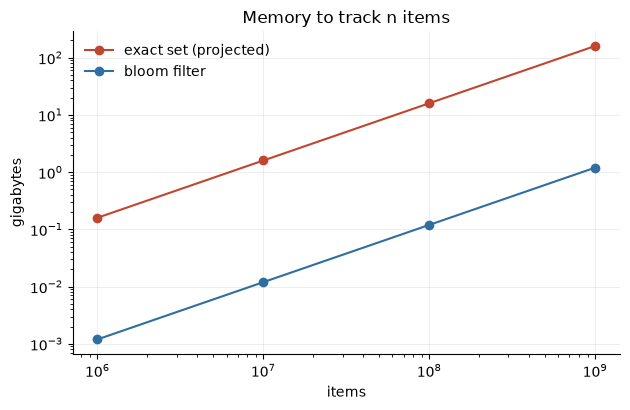

In [13]:
figure = plot_memory_projection(projection)
save_figure(figure, "03_billion_item_projection")
figure

In [14]:
one_billion = projection.iloc[-1]

saved = save_results(
    {
        "projection": projection,
        "bytes_per_exact_item_measured": float(
            one_billion["exact_set_bytes"] / one_billion["n_items"]
        ),
        "billion_items_bloom_gb": float(one_billion["bloom_bytes"] / 1e9),
        "billion_items_exact_gb": float(one_billion["exact_set_bytes"] / 1e9),
        "savings_factor": float(one_billion["savings_factor"]),
        "honest_claim": (
            "A billion items at a 1% false-positive rate needs about 1.2 GB of bits, not a "
            "megabyte; a megabyte holds about a million items. The saving is 133x against an "
            "exact set - one machine instead of a cluster - and it is projected from the sizing "
            "formula plus a measured per-item cost, never allocated."
        ),
    },
    "03_billion_item_projection",
)
print("saved ->", saved.name)

saved -> 03_billion_item_projection.json


## What to take away

- A Bloom filter is a bit array plus k hashes. It stores no keys, which is why it is tiny and why
  it can only answer *maybe / definitely not*.
- The error is **one-sided**: false positives at a rate you choose, false negatives never. That is
  the property that makes it correct for deduplication, caching, and "have I crawled this URL".
- Sizing is a formula, not a guess: `m = -n ln(p) / (ln 2)^2`, `k = (m/n) ln 2`, and about 9.6 bits
  per item at 1% regardless of `n`.
- Overfilling degrades it gracefully and one-sidedly - more false positives, never a false negative.
- Deletion needs the counting variant and 8x the memory. Usually you do not need it.
- At a billion items: ~1.2 GB instead of ~160 GB. Not magic, and not a megabyte - just 133x.

Next: the same primitive, asked a harder question. Not *have I seen this item*, but *how many
different items have I seen* - answered in 1.5 KB.

In [15]:
takeaways = [
    "A Bloom filter is a bit array plus k hashes, storing no keys at all.",
    "Its error is one-sided: tunable false positives, and never a false negative.",
    "Sizing is closed-form: ~9.6 bits per item at 1%, independent of the item count.",
    "Overfilling raises the false-positive rate; it never creates a false negative.",
    "A billion items at 1% is ~1.2 GB against ~160 GB exact - one machine instead of a cluster.",
]

saved = save_results({"takeaways": takeaways}, "03_takeaways")
print("saved ->", saved.name)
print("figures:", sorted(path.name for path in SETTINGS.figures.path.glob("03_*.png")))
print("results:", sorted(path.name for path in results_dir().glob("03_*.json")))

saved -> 03_takeaways.json
figures: ['03_billion_item_projection.png', '03_memory_vs_error.png']
results: ['03_billion_item_projection.json', '03_bloom_guarantee.json', '03_counting_bloom.json', '03_exact_vs_approximate.json', '03_memory_vs_error.json', '03_overfill.json', '03_takeaways.json']
